# "You Snooze, You Win" Challenge

Every year, the [PhysioNet/CinC (Computing in Cardiology) Challenge](https://www.physionet.org/challenge/) invites "participants to tackle clinically interesting problems that are either unsolved or not well-solved." For this year's week 2 machine learning challenge, BWSI has revived a past PhysioNet challenge based on sleep classification.

This year's challenge focuses on the classification of nonarousal and arousal timeframes. If you would like to understand the biological implications of the challenge, we recommend reading PhysioNet's [introduction](https://physionet.org/challenge/2018/) of the challenge.

For this challenge, you will classify samples into 5 classes (Arousal, NREM1, NREM2, NREM3, REM). Each sample consists of seven physiological signals (O2-M1, E1-M2, Chin1-Chin2, ABD, CHEST, AIRFLOW, ECG) measured at 200 Hz over a 60 second period (12000 timepoints). In this notebook, we provide code to import the data, visualize sample signals, implement an example classifier, and 'score' your model.

In [ ]:
### Import libraries ###

from google.colab import files
import matplotlib.pyplot as plt
import matplotlib

#set default plotting fonts
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 20}

matplotlib.rc('font', **font)

import numpy as np
import os
import pandas as pd
import random
from sklearn import metrics
from sklearn.utils import shuffle
import tensorflow as tf

## Loading the Dataset

This dataset is a modified version of the PhysioNet/CinC Challenge data, which were contributed by the Massachusetts General Hospital’s Computational Clinical Neurophysiology Laboratory, and the Clinical Data Animation Laboratory.
***
**Class labels:**
- 0 = Arousal
- 1 = NREM1
- 2 = NREM2
- 3 = NREM3
- 4 = REM
***
**Class descriptions:**

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/sleepStagesTable.svg?raw=true">

***
**Physiological signal description:**

O2-M1 - posterior brain activity (electroencephalography)

E1-M2 - left eye activity (electrooculography)

Chin1-Chin2 - chin movement (electromyography)

ABD - abdominal movement (electromyography)

CHEST - chest movement (electromyography)

AIRFLOW - respiratory airflow

ECG - cardiac activity (electrocardiography)
***
Run both cell blocks to get the challenge data.

In [ ]:
# Clone repo and move into data directory (only run this once)
!git clone https://github.com/BeaverWorksMedlytics2020/Data_Public
os.chdir('./Data_Public/ChallengeProjects/Week2/')

Cloning into 'Data_Public'...
remote: Enumerating objects: 5338, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 5338 (delta 28), reused 43 (delta 14), pack-reused 5274 (from 1)
Receiving objects: 100% (5338/5338), 1.11 GiB | 29.92 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Updating files: 100% (5134/5134), done.


## Loading Data in Memory
Run the cell below to extract the raw training and test data. It may take a minute or two to run through. Here are the variables containing the data you will get:

* **data_train**: np array shape (4000, 12000, 7). Contains 4000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **labels_train**: np array shape (4000,). Contains ground truth labels for data_train. The order of the labels corresponds to the order of the training data.
* **ID_train**: list of 4000 unique IDs. The order of the IDs corresponds to the order of the training data.
* **data_test**: np array shape (1000, 12000, 7). Contains 1000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **ID_test**: list of 1000 unique IDs. The order of the IDs corresponds to the order of the training data.

We encourage you to print each of these variables to see what they look like.

In [ ]:
### Run once to import data ###

def get_file_locs():
    '''
    find all files in 'training' and 'test' directories and put their names
    under 'training' and 'test' keys in the file_dict dictionary
    '''

    file_dict = {'training':[], 'test':[]}
    for data_type in file_dict:
        for file in os.listdir('./' + data_type):
            file_dict[data_type].append(data_type + '/' + file)

    return file_dict

def get_sample_data(data_type, id_number):
    '''
    get signal data, label, and filename associated with given data type and index num

    parameters:

     data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

     id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    returns:

     sample_data -- dataframe with 1 row and 2 columns-- column "Signal" contains a series object
                    and column "Label" contains numeric label for that sample
    '''
    file = './' + data_type + '/' + str(id_number) + '.xz'

    #sample_data is a dataframe with 1 row and 2 columns--
    #"Signal" (contains a series object) and "Label" (contains numeric label)
    sample_data = pd.read_pickle('./' + file)

    return sample_data, file.split('/')[2]

file_dict = get_file_locs()
print(f"{len(file_dict['training'])} training samples found, {len(file_dict['test'])} test samples found")

data_train = np.zeros((4000, 12000, 7))
labels_train = np.zeros(4000)
ID_train = []
for i in range(4000):
  sample_data, ID = get_sample_data('training', i)
  data_train[i] = np.array(list(sample_data['Signal']), dtype=float).reshape(12000, 7)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
  ID_train.append(ID)
  if(i%500==0):
    print('Loading training sample ' + str(i))

data_test = np.zeros((1000, 12000, 7))
ID_test = []
for i in range(1000):
  sample_data, ID = get_sample_data('test', i)
  data_test[i] = np.array(list(sample_data['Signal']), dtype=float).reshape(12000, 7)
  ID_test.append(ID)
  if(i%500==0):
    print('Loading test sample ' + str(i))

#keep original copy of data_train, labels_train, ID_train, data_test, and ID_test
# (for plotting or reference in case variables are shuffled later on)
data_train_orig = data_train.copy()
labels_train_orig = labels_train.copy()
ID_train_orig = ID_train.copy()
data_test_orig = data_test.copy()
ID_test_orig = ID_test.copy()

4000 training samples found, 1000 test samples found
Loading training sample 0


/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1

Loading training sample 500


/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1

Loading training sample 1000


...

Loading training sample 3000


/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1

Loading training sample 3500


/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1802/828924539.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_train[i] = np.array(list(sample_data['Label']), dtype=float)
/tmp/ipykernel_1

Loading test sample 0
Loading test sample 500


## Data Visualization

Run the cell below to visualize the raw data for a single 60s sample for all 7 signals. We strongly urge you to visualize a few different samples to get a feel for how the data looks and how much each signal can vary in amplitude and frequency from sample to sample. You can change which sample is being visualized by changing the arguments to the graph_signals call.

Training 2100 (NREM2)


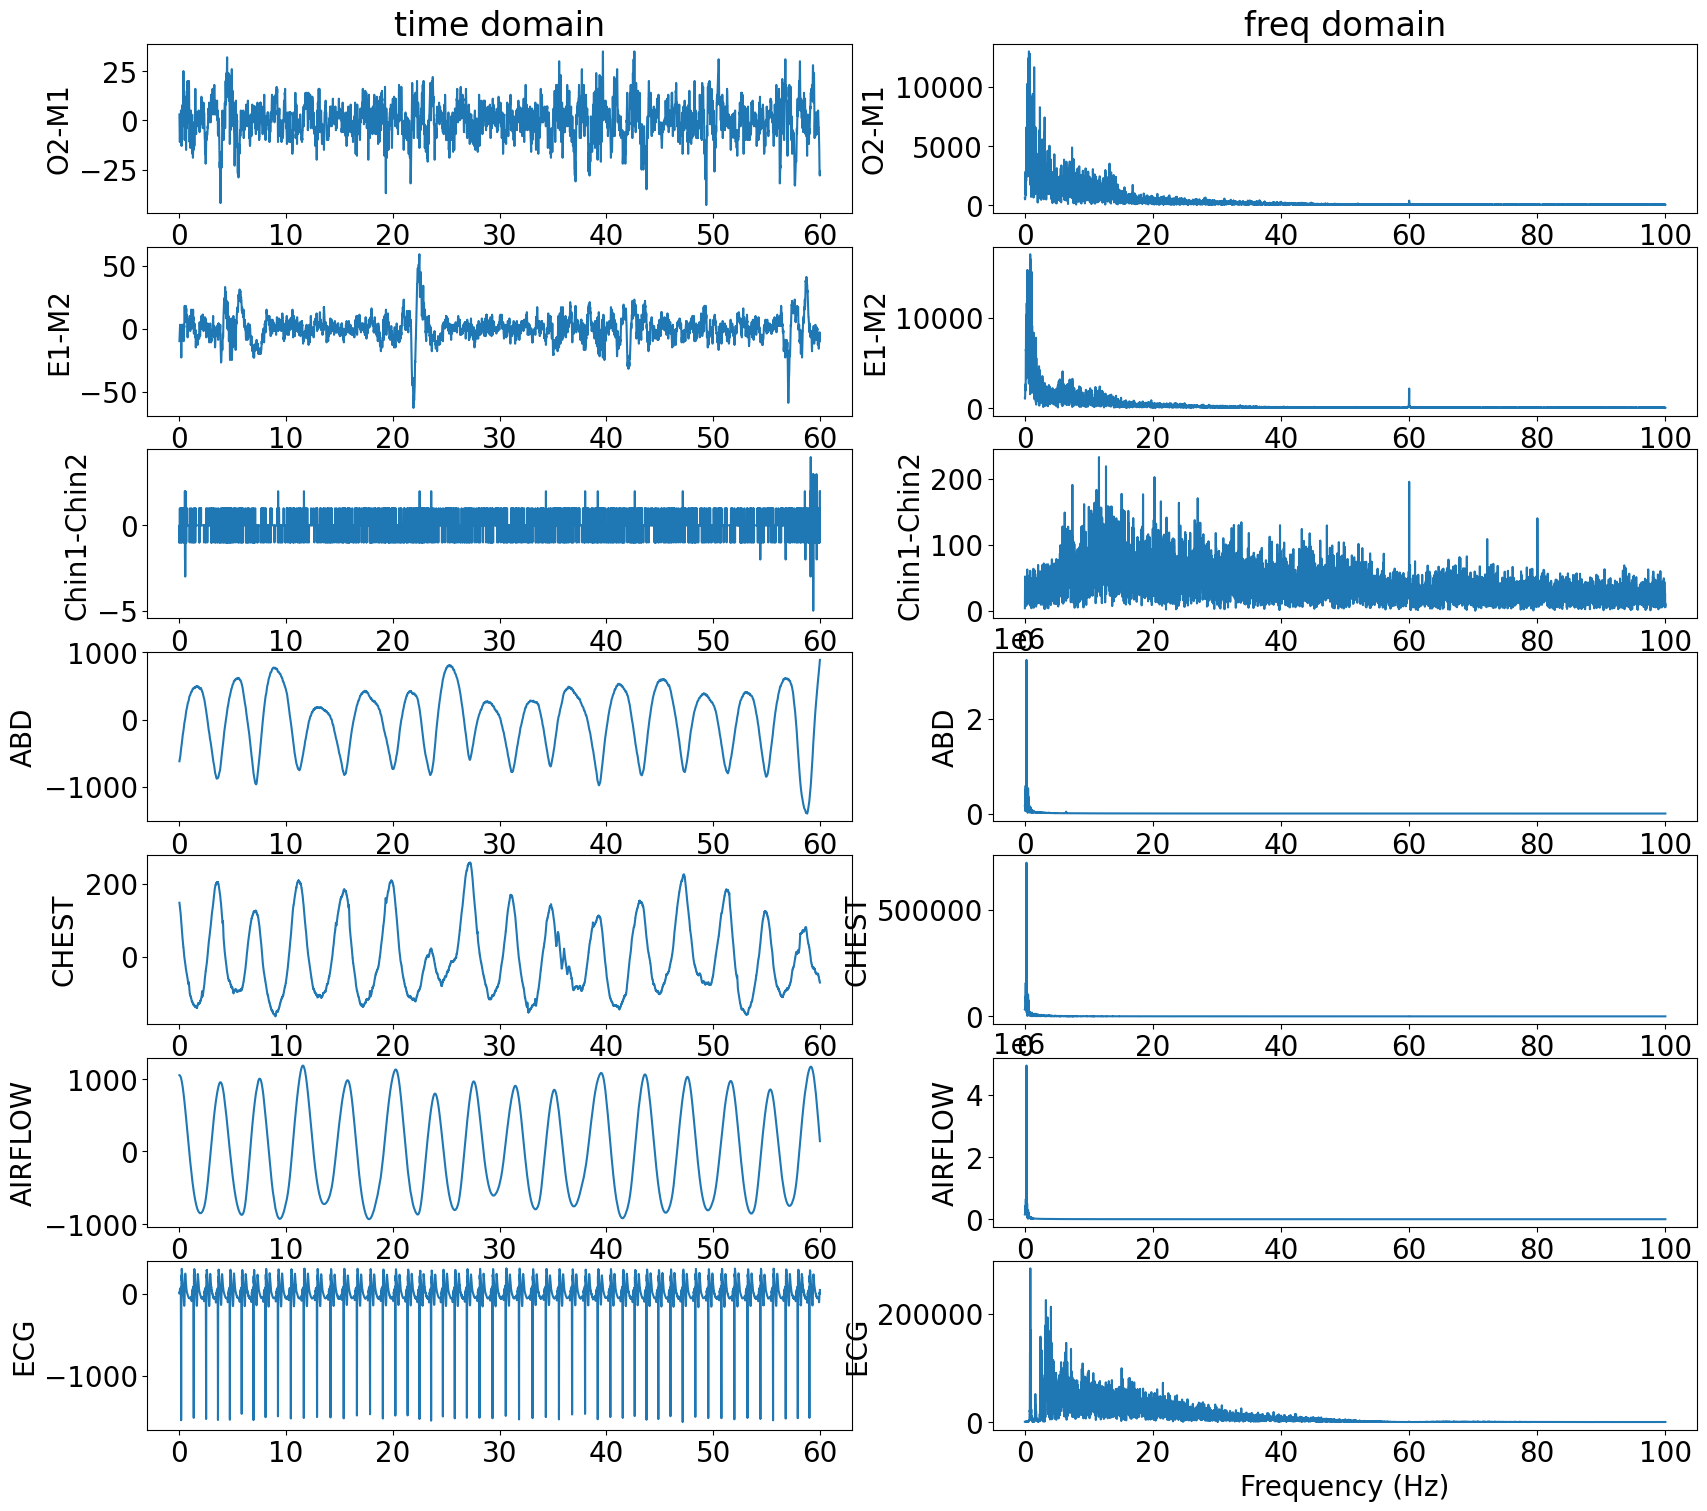

In [ ]:
### Define some useful functions to retrieve and plot data from individual samples ###

""" Initalize key reference dictionaries """
sig_dict = {0:'O2-M1', 1:'E1-M2', 2:'Chin1-Chin2', 3:'ABD', 4:'CHEST', 5:'AIRFLOW', 6:'ECG'}
sig_type_dict = {0:'Time (s)', 1:'Frequency (Hz)'}
stage_dict = {0:'Arousal', 1:'NREM1', 2:'NREM2', 3:'NREM3', 4:'REM'}

def graph_signals(data_type = 'training', id_number = None):
    '''
    Create a graph of multiple signals, with rows representing signal class, and
    columns representing signal domain (i.e. time or frequency)

    inputs:

      parameters:

      data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

      id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    '''

    assert data_type in ['test','training'], 'data_type should be either "test" or "training"'

    if id_number is None:
      if data_type == 'training':
        id_number = random.randint(0,3999)
      else:
        id_number = random.randint(0,999)

    #set time_signal_y based on 'test' or 'training' input
    if data_type == 'training':
        time_signal_y = data_train_orig[id_number,:,:]
    else:
        time_signal_y = data_test_orig[id_number,:,:]

    #Get signal values in time domain from either data_train_orig, or data_test_orig
    time_signal_x = np.arange(0, 60, step = 1/200) #this time axis doesn't change

    #Use time-domain signals to get frequency domain signals
    num_datapoints = time_signal_x.shape[0]
    freq_signal_x = np.arange(num_datapoints//2 + 1)/60
    freq_signal_y = np.ndarray(shape = (num_datapoints//2 + 1, 7))
    freq_signal_y = np.abs(np.fft.rfft(time_signal_y, axis = 0))

    plt.figure(figsize = (20, 18))
    title_list = ['time domain', 'freq domain']
    for signal_index in range(7): #7 classes of signal (O2-M1, E2-M2, etc.)
        for signal_domain_index in range(2): #2 types of signal (time and freq domain)
            plt.subplot(7, 2, 2*signal_index + signal_domain_index + 1)
            if signal_index==0:
                plt.title(title_list[signal_domain_index])
            if signal_domain_index == 0: #plot time domain signal
                plt.plot(time_signal_x, time_signal_y[:,signal_index])
            if signal_domain_index == 1: #plot freq domain signal
                plt.plot(freq_signal_x, freq_signal_y[:,signal_index])
            plt.ylabel(sig_dict[signal_index])
        plt.xlabel(sig_type_dict[signal_domain_index])
    plt.show()

# We can now use the above functions to retrieve data for a single sample
# (in the test or training set) and then plot it

#change these 2 lines to plot different samples (note that test set only has 1000 samples)
data_type = 'training'
id_number = random.randint(0,3999)

#print signal ID and the sample label (if known)
if data_type == 'training':
    print(data_type.title(), str(id_number), '(' + stage_dict[id_number//800] + ')')
else:
    print(data_type.title(), str(id_number), '(Unknown)')

#plot data from this sample
graph_signals(data_type = data_type, id_number = id_number)

## Example Classifier

Below is an example of a mediocre classifier for this dataset. It is a simple neural network that uses the spectral flatness of all signal classes its input features--that is, it has 7 input features.

While the example classifier makes use of a neural network, we encourage you to utilize any ML algorithm that you feel would be appropriate.

In [ ]:
### Define functions that calculate the features of a single sample ###

import scipy.stats.mstats as mstats

#I'm going to use spectral_flatness of the fft as a feature that could be used

def spectral_flatness(fft, zero_thresh = None):
  N = len(fft)
  magnitude = abs(fft[:N//2])* 2 / N

  if(zero_thresh is not None):
      magnitude[magnitude < zero_thresh] = zero_thresh

  if(any(magnitude<zero_thresh)):
    raise ValueError("THis shouldn't happen")

  sf = mstats.gmean(magnitude) / np.mean(magnitude)

  return sf

def get_features_for_single_sample(data_type = 'training', id_number = None):
    '''
    Calculate some number feature values for a single sample

    parameters:

      data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

      id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    returns:

      feature_vector -- 1d array containing all feature values for this sample
    '''

    assert data_type in ['test','training'], 'data_type should be either "test" or "training"'

    if id_number is None:
        id_number=random.randint(0,999)

    if data_type == 'training':
        time_signal_y = data_train_orig[id_number,:,:]
    else:
        time_signal_y = data_test_orig[id_number,:,:]

    #---Populate feature vector ---
    #(Example uses spectral flatness, but you can populate feature_vector with
    # anything that seems useful)

    #get an fft for all signals in this sample
    fft_arr = np.fft.rfft(time_signal_y, axis = 0)

    #Initialize feature vector to zeros of right size
    feature_vector = np.zeros((time_signal_y.shape[1],1))

    #Enumerate over all classes of signal, calculate spectral flatness for each and append value to feature_vector
    for ind in range(fft_arr.shape[1]): #for every class of signal
        feature_vector[ind] = spectral_flatness(fft_arr[:,ind], zero_thresh = 10**-10) #calculate spectral flatness and add it to a feature vector

    #---Finished populating feature vector---
    #(now feature_vector is populated with hand-engineered features for this sample)

    return feature_vector

def get_features(data_type, num_samples):
    '''
    Retrieve features from num_samples samples in either test or training set,
    return features for each sample and index of each sample

    inputs:

      data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

      num_samples -- For how many samples should features be calculated?
                  (should not exceed total samples in a given data_type)

    returns:

      features -- n x p array of feature values for all samples where rows
                  correspond to samples and columns correspond to feature number

      order -- 1d array where index i contains the index of row i of the feature vector
               (only needed if shuffling takes place later)
    '''

    features, order = np.array([]), np.array([])
    for i in range(num_samples):
        single_sample_features = get_features_for_single_sample(data_type = data_type, id_number = i)
        features = np.hstack((features, single_sample_features)) if features.size else single_sample_features
        order = np.append(order, i).astype(np.float32)

    #ensure features are of type float32
    features = features.astype(np.float32)

    return np.transpose(features), order


In [ ]:
### Run every time you modify your feature extraction ###

print('calculating features for training data...')
train_data, train_order = get_features('training', 4000)


print('calculating features for test data...')
test_data, test_order = get_features('test', 1000)


calculating features for training data...
calculating features for test data...


## Visualize Entire Dataset's Features

In [ ]:
### Create label array for all training samples using categorical datatype ###

train_labels = np.ndarray(shape = (1, 4000))

#set labels to integers first
for i in range(4000):
    train_labels[0][i] = i//800 # This is a way to label each entry (since classes are in order)

#convert labels to onehot, ensure type is float32
train_labels = tf.keras.utils.to_categorical(train_labels[0], 5)
train_labels = train_labels.astype(np.float32)


In [ ]:
### Run whenever you want to check or view your data and labels ###
print(f"train_data.shape = {train_data.shape} \n train_labels.shape = {train_labels.shape}\n\n")
print(f"train data:\n {train_data}\n\ntrain labels:\n {train_labels}")
#plot feature values and label values to show data clearly
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize= (30,15))

#Note: if your features are not scaled to the range 0->1 you might want to change vmin and vmax
featureImg = ax1.imshow(train_data[:,:], aspect = 'auto', interpolation = 'None')# vmin = 0, vmax = 1.0)
ax1.set_title('Feature Values')
ax1.set_ylabel('Sample Number')
ax1.set_xlabel('Feature Number')
fig.colorbar(featureImg, ax = ax1, boundaries = np.linspace(0.0, 1.0, 50), ticks = [0,0.5,1])

from matplotlib.colors import ListedColormap
bw_cmap = ListedColormap(np.array([[0,0,0,1],[1,1,1,1]])) # make a colormap manually
labelImg = ax2.imshow(train_labels, aspect = 'auto', cmap = bw_cmap,interpolation = 'None', vmin = 0, vmax = 1.0)
ax2.set_title('Label Values')
ax2.set_xlabel('Label')
ax2.set_xticks(range(len(stage_dict)))
ax2.set_xticklabels([stage_dict[i] for i in range(len(stage_dict))])
fig.colorbar(labelImg, ax = ax2, boundaries = np.linspace(-0.5, 1.5,3), ticks = [0, 1])

NameError: name 'train_data' is not defined

In [ ]:
#### Run every time you modify your feature extraction ###
#
# This cell splits up the labeled data into 3 subsets (training data, validation
# data, and test data)
#
# This 3-way split is very common in training a supervised learning model. The purpose of
# each partition is as follows:
#
# 1) Training data is used to adjust model weights (so-called model parameters)
# 2) Validation data is used to gauge how well model generalizes (allowing user
#    to compare between different trained models and/or non-trained model
#    parameters (hyperparameters))
# 3) Test data is used to provide an indicator of real-world performance (it
#    should not be used when deciding between models because this would result
#    in overfitting!)

train_data_shuffled, train_labels_shuffled = shuffle(train_data, train_labels, random_state = 25)

""" val_size (int) must be from 0-4000 """
val_size = 1000
mocktest_size = 500

val_data = train_data_shuffled[:val_size]
mocktest_data = train_data_shuffled[val_size:val_size + mocktest_size]
partial_train_data = train_data_shuffled[val_size + mocktest_size:]

val_labels = train_labels_shuffled[:val_size]
mocktest_labels = train_labels_shuffled[val_size:val_size + mocktest_size]
partial_train_labels = train_labels_shuffled[val_size + mocktest_size:]

training_set = tf.data.Dataset.from_tensor_slices((partial_train_data, partial_train_labels))
training_set = training_set.batch(40) #set batch size


In [ ]:
### Run every time you change set of parameters ###

model = tf.keras.Sequential()

""" Modify to your heart's and algorithm's content ^_^ """

model.add(tf.keras.layers.Dense(64, activation=tf.nn.relu, input_shape=(train_data.shape[1],)))
model.add(tf.keras.layers.Dense(64, activation=tf.nn.relu))
# we should end with a softmax to ensure outputs behave like probabilities
#(i.e. sum to 1)
model.add(tf.keras.layers.Dense(5, activation=tf.nn.softmax))

opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
#Another potential optimizer
#opt = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,997 (19.52 KB)

 Trainable params: 4,997 (19.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Run whenever you want to train and validate your model ###

"""
EPOCHS (int) the number of times the optimization algorithm passes
through the full dataset (calculating errors and derivatives) to update weights
(One pass through the data is called an "epoch")
"""

EPOCHS = 50

for epoch in range(EPOCHS):
    for signals, labels in training_set:
        tr_loss, tr_accuracy = model.train_on_batch(signals, labels)
    val_loss, val_accuracy = model.evaluate(val_data, val_labels)
    print(('Epoch #%d\t Training Loss: %.2f\tTraining Accuracy: %.2f\t'
         'Validation Loss: %.2f\tValidation Accuracy: %.2f')
         % (epoch + 1, tr_loss, tr_accuracy,
         val_loss, val_accuracy))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2630 - loss: 1.6076
Epoch #1	 Training Loss: 1.61	Training Accuracy: 0.26	Validation Loss: 1.61	Validation Accuracy: 0.26
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2770 - loss: 1.6042
Epoch #2	 Training Loss: 1.61	Training Accuracy: 0.27	Validation Loss: 1.60	Validation Accuracy: 0.28
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2880 - loss: 1.6009
Epoch #3	 Training Loss: 1.60	Training Accuracy: 0.28	Validation Loss: 1.60	Validation Accuracy: 0.29
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2990 - loss: 1.5976
Epoch #4	 Training Loss: 1.60	Training Accuracy: 0.29	Validation Loss: 1.60	Validation Accuracy: 0.30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3150 - loss: 1.5945
Epoch #5	 Training Loss: 1.60	Training Accuracy: 0.31	Validation Loss: 1.59	Validation Accuracy: 0.31
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3230 - loss: 1.5916 
Epoch #6	 Training Loss: 1.59	Training Accuracy: 0.

In [ ]:
### Run once after you have finished training your model ###

test_pred = model.predict(test_data)
test_output = np.ndarray(shape = (1000, 6))

# """ Add column with file number """
for i in range(1000):
    test_output[i] = np.append(test_pred[i], test_order[i])
test_dataframe = pd.DataFrame(test_output)

""" Sort dataframe according to file number """
sorted_test_dataframe = test_dataframe.sort_values(by=[5])

""" Drop file number column """
processed_test_dataframe = sorted_test_dataframe.drop(sorted_test_dataframe.columns[5], axis=1)

print(test_dataframe.head(), '\n\n', sorted_test_dataframe.head(), '\n\n', processed_test_dataframe.head())

# file = 'SquashisGreatL.xz'
# processed_test_dataframe.to_pickle(file)
# test_dataframe = pd.DataFrame(test_output)
# os.listdir('.')
# files.download(file)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
          0         1         2         3         4    5
0  0.083804  0.121061  0.208207  0.333768  0.253159  0.0
1  0.253134  0.321450  0.173955  0.084653  0.166807  1.0
2  0.201939  0.220224  0.210843  0.164111  0.202882  2.0
3  0.190323  0.153939  0.214096  0.252823  0.188819  3.0
4  0.247210  0.225646  0.203529  0.147362  0.176253  4.0 

           0         1         2         3         4    5
0  0.083804  0.121061  0.208207  0.333768  0.253159  0.0
1  0.253134  0.321450  0.173955  0.084653  0.166807  1.0
2  0.201939  0.220224  0.210843  0.164111  0.202882  2.0
3  0.190323  0.153939  0.214096  0.252823  0.188819  3.0
4  0.247210  0.225646  0.203529  0.147362  0.176253  4.0 

           0         1         2         3         4
0  0.083804  0.121061  0.208207  0.333768  0.253159
1  0.253134  0.321450  0.173955  0.084653  0.166807
2  0.201939  0.220224  0.210843  0.164111  0.202882
3  0.190323  0.153939  0.214096  0.252823  0.188819
4  0.247210

## Submitting Your Model

After training your classifier, run it on the test data to generate your predictions. Each class for a test sample should have an associated probability (between 0 and 1). Below are the parameters for the prediction format and export:

- Your predictions should be in a pandas dataframe with 5 columns (classes) and 1000 rows (samples). Note that your predictions must follow the original test sample order (0.xz, 1.xz, 2.xz, ...). You only need to worry about this if you shuffled the test samples or stored the samples in an unordered data structure (dictionaries and sets). If this is the case, you should 1) add a separate column in your pandas dataframe with the file number for each sample; 2) sort the dataframe using this column; and 3) drop the column. These steps have been noted in the code below.
- The predictions dataframe should be exported as an .xz file using dataframe.to_pickle() followed by files.download().

Example code of the prediction format and export is presented in the cell block below.

Your model will be evaluated on Area Under the ROC Curve (ROCAUC), Matthews Correlation Coefficient (MCC) and creativity. There will be a "winning" group for each of these categories.

If you are finished early, consider trying other ML algorithms and/or implementing multiple feature extraction methods. You can also help other groups if you finish early.

## How Your Model Will Be Evaluated

- **Area Under the ROC Curve (AUCROC)**: The receiver operating characteristic (ROC) curve plots the true positive rate (sensitivity/recall) against the false positive rate (fall-out) at many decision threshold settings. The area under the curve (AUC) measures discrimination, the classifier's ability to correctly identify samples from the "positive" and "negative" cases. Intuitively, AUC is the probability that a randomly chosen "positive" sample will be labeled as "more positive" than a randomly chosen "negative" sample. In the case of a multi-class ROC curve, each class is considered separately before taking the weighted average of all the class results. Simply put, the class under consideration is labeled as "positive" while all other classes are labeled as "negative." Below is the multi-class ROC curve for the example classifier. The AUCROC score should be between 0 and 1, in which 0.5 is random classification and 1 is perfect classification.

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/MultiClassRocCurve_exampleClassifier.png?raw=true" width="600" height="500">

- **Matthews Correlation Coefficient (MCC)**: The MCC measures the quality of binary classifications, irrespective of the class sizes. Importantly, it is typically regarded as a balanced measure since it considers all values in the 2x2 contingency table (TP, FP, TN, FN). For this challenge, the binary classes will be "Arousal" (Arousal) and "Nonarousal" (NREM1, NREM2, NREM3, REM). The MCC score should be between -1 and 1, in which 0 is random classification and 1 is perfect classification.

 ![alt text](https://wikimedia.org/api/rest_v1/media/math/render/svg/5caa90fc15105b74b59a30bbc9cc2e5bd43a13b7)

Using these metrics, the example classifier has the following scores on test data:
- AUCROC: 0.727
- MCC: 0.163
- Creativity: ( ͡° ͜ʖ ͡°)

Below is the code used to calculate the AUCROC and MCC metrics when evaluating your classifier.

In [ ]:
test_pred = pd.DataFrame(model.predict(mocktest_data))
test_predict = test_pred.idxmax(axis=1)
test_labels = [ np.where(label==1)[0][0] for label in mocktest_labels]
test_labels_one_hot = pd.DataFrame(mocktest_labels)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


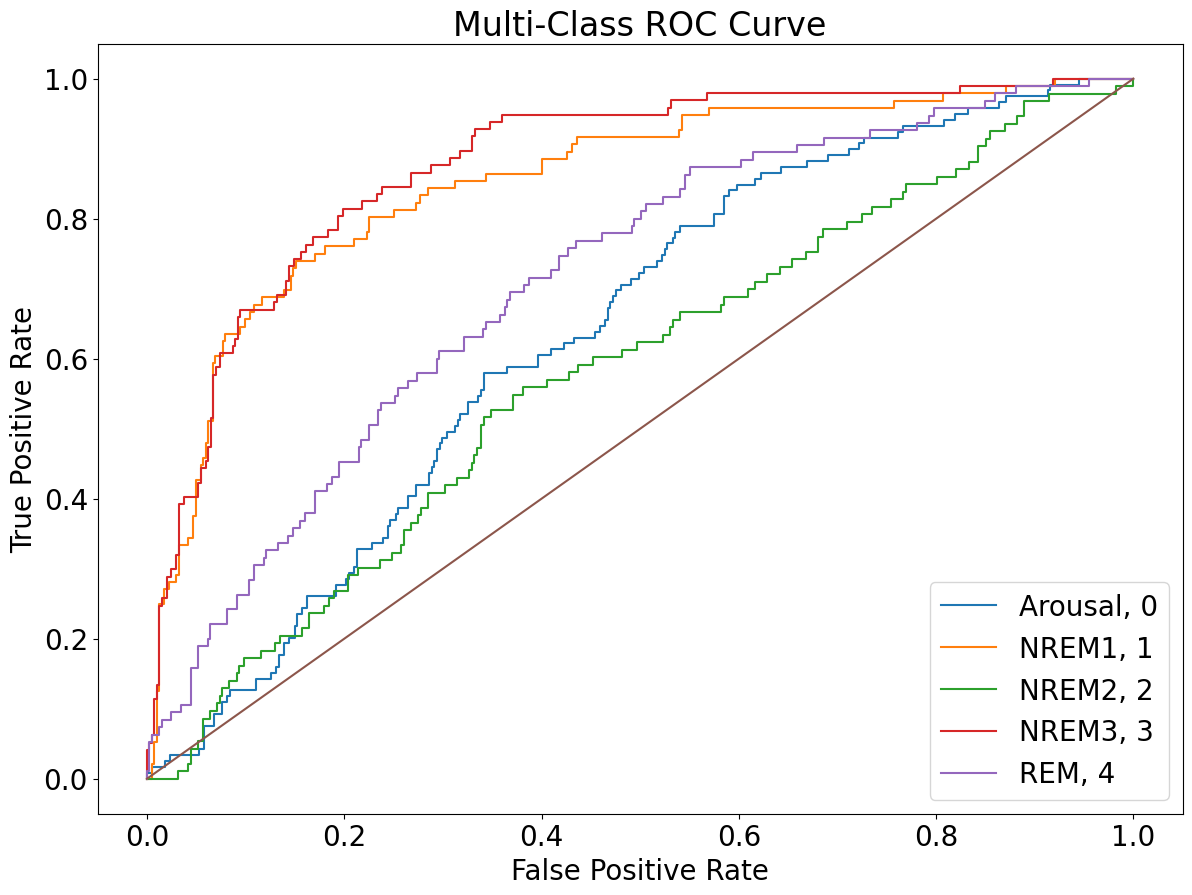

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(14,10))
for i in range(5):
    fpr[i], tpr[i], _ = metrics.roc_curve(test_labels_one_hot.iloc[:, i], test_pred.iloc[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label = stage_dict[i] + ', ' + str(i))

plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

fpr["micro"], tpr["micro"], _ = metrics.roc_curve(test_labels_one_hot.values.ravel(), test_pred.values.ravel())
roc_auc_agg = metrics.auc(fpr["micro"], tpr["micro"])

In [ ]:
y_true = []
y_pred = []
for i in range(test_pred.shape[0]):
    if test_predict.iloc[i]==0: y_pred.append(1)
    else: y_pred.append(-1)
    if test_labels[i]==0: y_true.append(1)
    else: y_true.append(-1)
mcc = metrics.matthews_corrcoef(y_true, y_pred)

In [ ]:
print(roc_auc_agg, mcc)

0.743253 0.1533756540281892


### CNN Multi Branch
Divides Signals into 3 groups and creates individual CNNs for each group which we finally combine together

- Group 1 (EEG/EOG/chin): O2-M1, E1-M2, Chin1-Chin2
- Group 2 (respiratory): ABD, CHEST, AIRFLOW
- Group 3 (cardiac): ECG

In [ ]:
from sklearn.model_selection import train_test_split

down_size = 4


def down_size_sample (data, factor):
  n_samples, n_timepoints, n_signals = data.shape
  trimmed_len = (n_timepoints // factor) * factor
  data_trimmed = data[:, :trimmed_len, :]
  reshaped = data_trimmed.reshape(n_samples, trimmed_len // factor, factor, n_signals)
  return reshaped.mean(axis=2)

data_train_ds = down_size_sample(data_train_orig, down_size)
print(f"Downsized shape: {data_train_ds.shape}")

signal_mean = data_train_ds.mean(axis=(0, 1), keepdims=True)
signal_std = data_train_ds.std(axis=(0, 1), keepdims=True) + 1e-8
data_train_norm = (data_train_ds - signal_mean) / signal_std

g1_idx = [0,1,2]
g2_idx = [3,4,5]
g3_idx = [6]

g1_data = data_train_norm[:, :, g1_idx]
g2_data = data_train_norm[:, :, g2_idx]
g3_data = data_train_norm[:, :, g3_idx]


Downsized shape: (4000, 3000, 7)


In [ ]:
indices = np.arange(data_train_norm.shape[0])
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=25, stratify=train_labels.argmax(axis=1))

g1_train, g1_val = g1_data[train_idx], g1_data[val_idx]
g2_train, g2_val = g2_data[train_idx], g2_data[val_idx]
g3_train, g3_val = g3_data[train_idx], g3_data[val_idx]

labels_a_train, labels_a_val = train_labels[train_idx], train_labels[val_idx]

In [ ]:
def make_branch(input_shape, name_prefix):
    branch_input = tf.keras.Input(shape=input_shape, name=f'{name_prefix}_input')
    x = tf.keras.layers.Conv1D(16, kernel_size=7, activation='relu', padding='same')(branch_input)
    x = tf.keras.layers.MaxPooling1D(pool_size=4)(x)
    x = tf.keras.layers.Conv1D(32, kernel_size=5, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=4)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    return branch_input, x

input1, branch1_out = make_branch(g1_train.shape[1:], 'eeg_eog_chin')
input2, branch2_out = make_branch(g2_train.shape[1:], 'respiratory')
input3, branch3_out = make_branch(g3_train.shape[1:], 'ecg')

merged = tf.keras.layers.Concatenate()([branch1_out, branch2_out, branch3_out])
x = tf.keras.layers.Dense(32, activation='relu')(merged)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(5, activation='softmax')(x)

model_a = tf.keras.Model(inputs=[input1, input2, input3], outputs=output)

opt_a = tf.keras.optimizers.Adam(learning_rate=0.0005)
model_a.compile(loss='categorical_crossentropy', optimizer=opt_a, metrics=['accuracy'])

model_a.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_eog_chin_input  │ (None, 3000, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ respiratory_input   │ (None, 3000, 3)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ecg_input           │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3000, 16)  │        352 │ eeg_eog_chin_inp… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 3000, 16)  │        352 │ respiratory_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 3000, 16)  │        128 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 750, 16)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 750, 16)   │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 750, 16)   │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 750, 32)   │      2,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 750, 32)   │      2,592 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 750, 32)   │      2,592 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 187, 32)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 187, 32)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 187, 32)   │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling1d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling1d_3[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ max_pooling1d_5[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ global_average_p

 Total params: 11,877 (46.39 KB)

 Trainable params: 11,877 (46.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS_A = 35
BATCH_SIZE_A = 30

early_stop_a = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_a = model_a.fit(
    [g1_train, g2_train, g3_train],
    labels_a_train,
    validation_data=([g1_val, g2_val, g3_val], labels_a_val),
    epochs=EPOCHS_A,
    batch_size=BATCH_SIZE_A,
    callbacks=[early_stop_a],
    verbose=1
)

Epoch 1/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.5597 - loss: 1.0597 - val_accuracy: 0.5987 - val_loss: 1.0490
Epoch 2/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.5591 - loss: 1.0570 - val_accuracy: 0.5775 - val_loss: 1.0199
Epoch 3/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.5481 - loss: 1.0647 - val_accuracy: 0.5962 - val_loss: 1.0038
Epoch 4/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.5469 - loss: 1.0390 - val_accuracy: 0.5950 - val_loss: 1.0039
Epoch 5/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.5638 - loss: 1.0388 - val_accuracy: 0.5925 - val_loss: 1.0103
Epoch 6/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.5825 - loss: 1.0297 - val_accuracy: 0.5938 - val_loss: 0.9881
Epoch 7/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 153ms/step - accuracy: 0.5678 - loss: 1.0374 - val_accuracy: 0.6100 - val_loss: 0.9842
Epoch 8/35
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 155ms/step - accuracy: 0.5741 - loss: 1

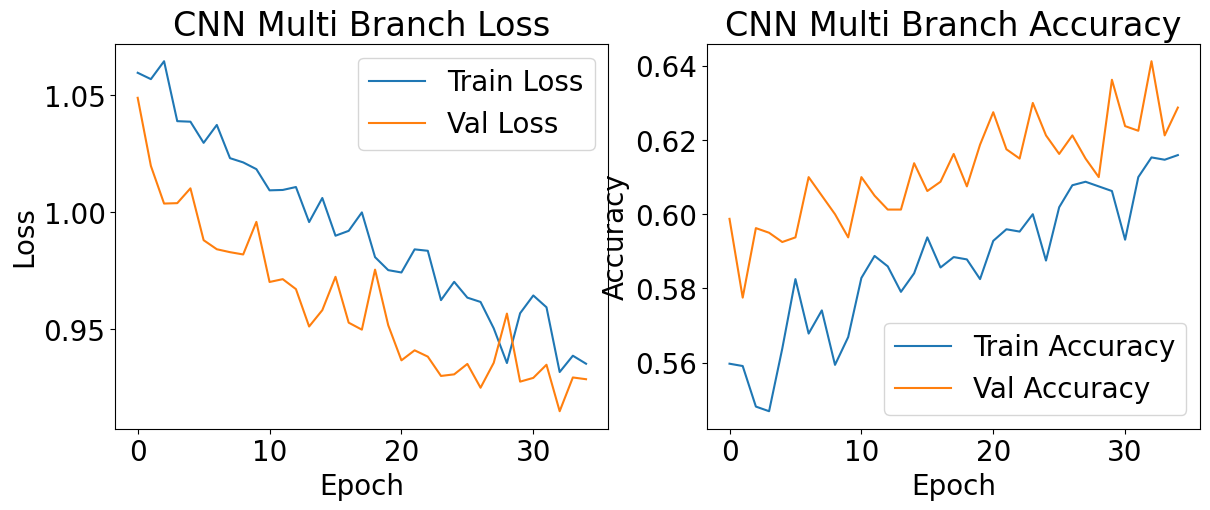

0.6159374713897705 0.6287500262260437


In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_a.history['loss'], label='Train Loss')
plt.plot(history_a.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Multi Branch Loss')

plt.subplot(1, 2, 2)
plt.plot(history_a.history['accuracy'], label='Train Accuracy')
plt.plot(history_a.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Multi Branch Accuracy')
plt.show()


model_a_train_acc = history_a.history['accuracy'][-1]
model_a_val_acc = history_a.history['val_accuracy'][-1]

print(model_a_train_acc, model_a_val_acc)

In [ ]:
val_pred_a = pd.DataFrame(model_a.predict([g1_val, g2_val, g3_val]))
val_predict_a = val_pred_a.idxmax(axis=1)
val_labels_a_int = [np.where(label==1)[0][0] for label in labels_a_val]
val_labels_a_onehot = pd.DataFrame(labels_a_val)

fpr_a, tpr_a, roc_auc_a = {}, {}, {}
for i in range(5):
    fpr_a[i], tpr_a[i], _ = metrics.roc_curve(val_labels_a_onehot.iloc[:, i], val_pred_a.iloc[:, i])
    roc_auc_a[i] = metrics.auc(fpr_a[i], tpr_a[i])

fpr_a['micro'], tpr_a['micro'], _ = metrics.roc_curve(val_labels_a_onehot.values.ravel(), val_pred_a.values.ravel())
roc_auc_agg_a = metrics.auc(fpr_a['micro'], tpr_a['micro'])

y_true_a, y_pred_a = [], []
for i in range(val_pred_a.shape[0]):
    y_pred_a.append(1 if val_predict_a.iloc[i]==0 else -1)
    y_true_a.append(1 if val_labels_a_int[i]==0 else -1)
mcc_a = metrics.matthews_corrcoef(y_true_a, y_pred_a)

print(roc_auc_agg_a, mcc_a)



25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
0.900100390625 0.27783603889038105


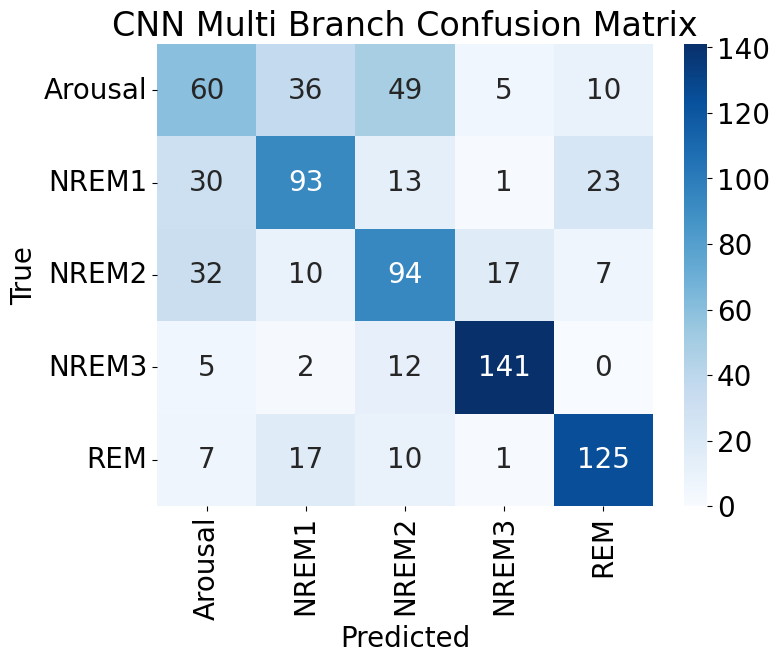

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(val_labels_a_int, val_predict_a)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[stage_dict[i] for i in range(5)],
            yticklabels=[stage_dict[i] for i in range(5)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Multi Branch Confusion Matrix')
plt.show()

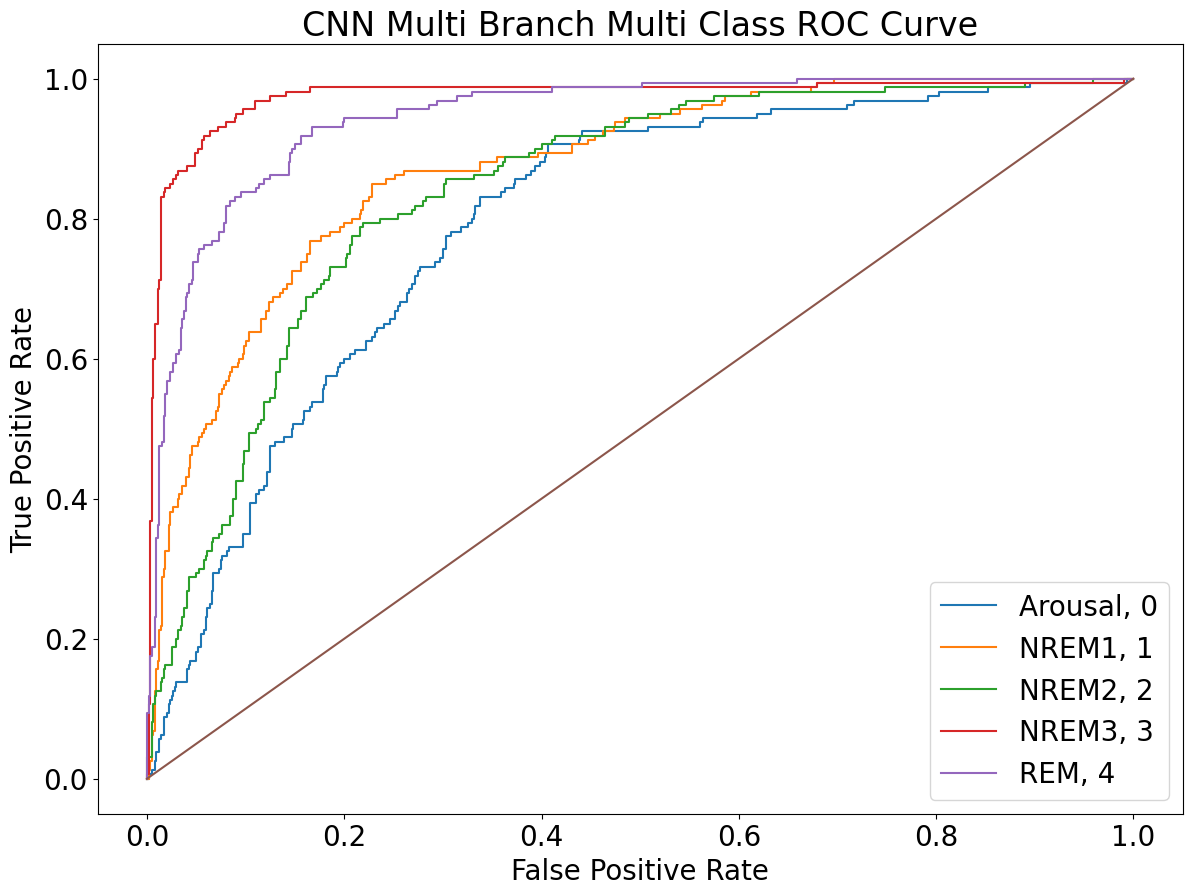

In [ ]:
fpr_a, tpr_a, roc_auc_a = {}, {}, {}

plt.figure(figsize=(14, 10))
for i in range(5):
    fpr_a[i], tpr_a[i], _ = metrics.roc_curve(val_labels_a_onehot.iloc[:, i], val_pred_a.iloc[:, i])
    roc_auc_a[i] = metrics.auc(fpr_a[i], tpr_a[i])
    plt.plot(fpr_a[i], tpr_a[i], label=stage_dict[i] + ', ' + str(i))

plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN Multi Branch Multi Class ROC Curve')
plt.legend()
plt.show()

fpr_a['micro'], tpr_a['micro'], _ = metrics.roc_curve(val_labels_a_onehot.values.ravel(), val_pred_a.values.ravel())
roc_auc_agg_a = metrics.auc(fpr_a['micro'], tpr_a['micro'])

###Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import scipy.stats.mstats as mstats

In [ ]:
def extract_rf_features_single(data_type="training", id_number = None):
  if data_type == "training":
    signal = data_train_orig[id_number, :, :]
  else:
    signal = data_test_orig[id_number, :, :]

  fft_array = np.fft.rfft(signal, axis = 0)
  features = []
  for ch in range(signal.shape[1]):
    channel = signal[:,ch]
    magnitude = np.abs(fft_array[1:,ch])
    features.append(np.mean(channel)) #average
    features.append(np.std(channel)) #standard devicaition
    features.append(np.sum(magnitude**2)) #total energy
    features.append(np.argmax(magnitude)) #dominant frequency

    magnitude_noise = np.clip(magnitude, 1e-10, None)
    sf = mstats.gmean(magnitude_noise) / np.mean(magnitude_noise) #spectral flatness
    features.append(sf)

  return np.array(features)


def extract_rf_features(data_type, num_samples):
  all_features = []
  for i in range(num_samples):
    all_features.append(extract_rf_features_single(data_type, i))
  return np.array(all_features)


print("Getting training features")
rf_train_features = extract_rf_features("training", 4000)
print("Getting test features")
rf_test_features = extract_rf_features("test", 1000)

print(rf_train_features.shape)

Getting training features
Getting test features
(4000, 35)


In [ ]:
rf_labels = np.array([i // 800 for i in range(4000)])

rf_train_data = rf_train_features[train_idx]
rf_val_data = rf_train_features[val_idx]

rf_train_labels = rf_labels[train_idx]
rf_val_labels = rf_labels[val_idx]

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=25, n_jobs=-1)
rf_model.fit(rf_train_data, rf_train_labels)

val_predictions = rf_model.predict(rf_val_data)
print(f"Validation accuracy: {np.mean(val_predictions == rf_val_labels):.3f}")

Validation accuracy: 0.635


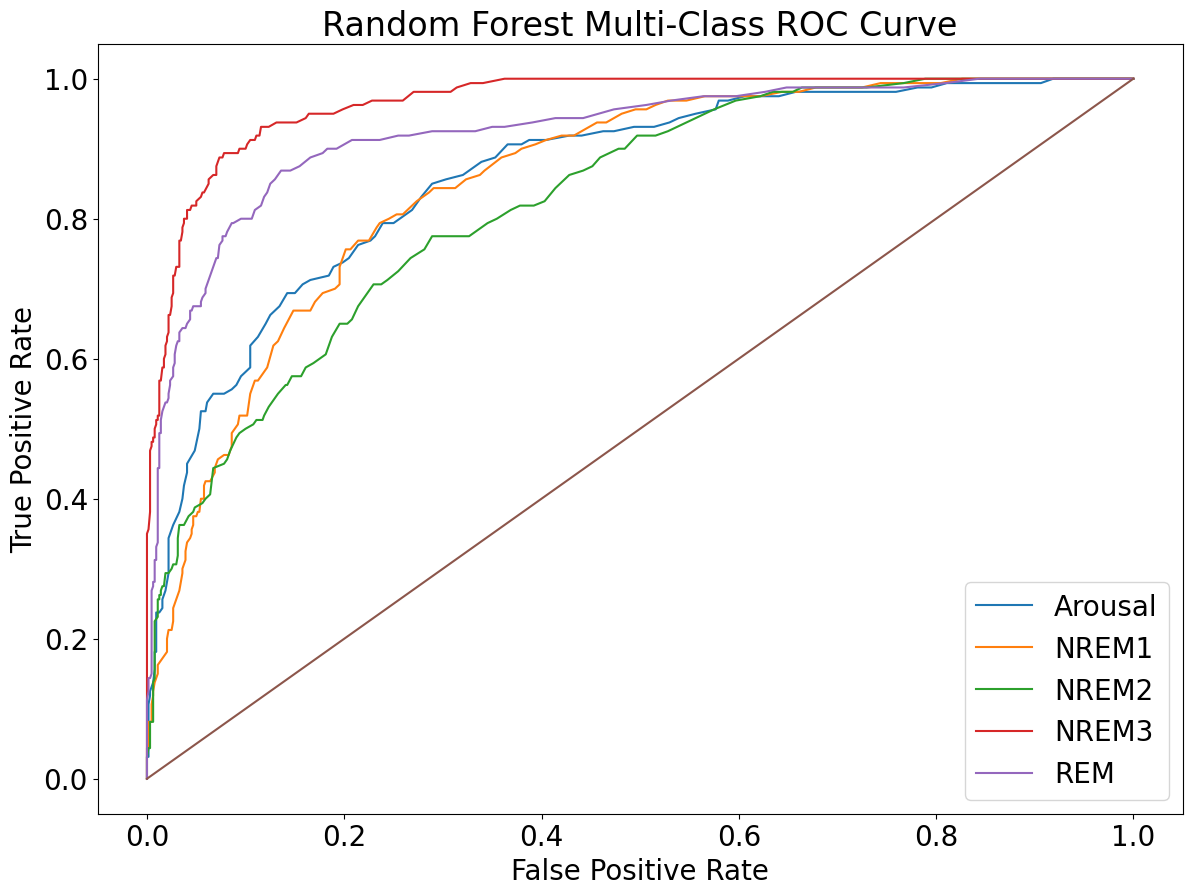

In [ ]:
rf_probs = rf_model.predict_proba(rf_val_data)

rf_val_pred = pd.DataFrame(rf_probs)
rf_val_predict = rf_val_pred.idxmax(axis=1)
rf_val_labels_one_hot = pd.DataFrame(tf.keras.utils.to_categorical(rf_val_labels, 5))

rf_fpr, rf_tpr, rf_roc_auc = {}, {}, {}

plt.figure(figsize=(14,10))
for i in range(5):
    rf_fpr[i], rf_tpr[i], _ = metrics.roc_curve(rf_val_labels_one_hot.iloc[:, i], rf_val_pred.iloc[:, i])
    rf_roc_auc[i] = metrics.auc(rf_fpr[i], rf_tpr[i])
    plt.plot(rf_fpr[i], rf_tpr[i], label=stage_dict[i])

plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Multi-Class ROC Curve')
plt.legend()
plt.show()

rf_fpr["micro"], rf_tpr["micro"], _ = metrics.roc_curve(rf_val_labels_one_hot.values.ravel(), rf_val_pred.values.ravel())
rf_roc_auc_agg = metrics.auc(rf_fpr["micro"], rf_tpr["micro"])

In [ ]:
y_true, y_pred = [], []
for i in range(rf_val_pred.shape[0]):
    y_pred.append(1 if rf_val_predict.iloc[i]==0 else -1)
    y_true.append(1 if rf_val_labels[i]==0 else -1)
rf_mcc = metrics.matthews_corrcoef(y_true, y_pred)

In [ ]:
print(rf_roc_auc_agg, rf_mcc)

0.89407890625 0.45575917090544843


### Neural Network

In [ ]:
def sf_spectral_flatness(fft, zero_thresh=None):
    N = len(fft)
    magnitude = abs(fft[:N//2]) * 2 / N
    if zero_thresh is not None:
        magnitude[magnitude < zero_thresh] = zero_thresh
    sf = mstats.gmean(magnitude) / np.mean(magnitude)
    return sf

def sf_spectral_centroid(fft, sample_rate=200):
    N = len(fft)
    magnitude = abs(fft[:N//2]) * 2 / N
    frequencies = np.fft.fftfreq(N, d=1/sample_rate)[:N//2]
    if np.sum(magnitude) == 0:
        return 0
    return np.sum(frequencies * magnitude) / np.sum(magnitude)

def sf_spectral_rolloff(ft, f_s):
    num_samples = len(ft)
    freqs = np.linspace(0, f_s, num_samples)[:num_samples // 2]
    magnitude = np.abs(ft[:num_samples // 2])
    whole_sum = np.sum(magnitude)
    cumulative_sum = 0.0
    for k, ft_mag in enumerate(magnitude):
        cumulative_sum += ft_mag
        if cumulative_sum >= 0.85 * whole_sum:
            return freqs[k]
    return freqs[-1]

def sf_get_features_for_single_sample(data_type='training', id_number=None):
    if data_type == 'training':
        time_signal_y = data_train_orig[id_number, :, :]
    else:
        time_signal_y = data_test_orig[id_number, :, :]

    fft_arr = np.fft.rfft(time_signal_y, axis=0)
    feature_vector = np.zeros((time_signal_y.shape[1] * 3, 1))

    for ind in range(fft_arr.shape[1]):
        feature_vector[ind * 3] = sf_spectral_centroid(fft_arr[:, ind], sample_rate=200)
        feature_vector[ind * 3 + 1] = sf_spectral_flatness(fft_arr[:, ind], zero_thresh=10**-10)
        feature_vector[ind * 3 + 2] = sf_spectral_rolloff(fft_arr[:, ind], 200)

    return feature_vector

def sf_get_features(data_type, num_samples):
    features, order = np.array([]), np.array([])
    for i in range(num_samples):
        single_sample_features = sf_get_features_for_single_sample(data_type=data_type, id_number=i)
        features = np.hstack((features, single_sample_features)) if features.size else single_sample_features
        order = np.append(order, i).astype(np.float32)
    features = features.astype(np.float32)
    return np.transpose(features), order

print('calculating spectral features for training data...')
sf_train_features, sf_train_order = sf_get_features('training', 4000)
print('calculating spectral features for test data...')
sf_test_features, sf_test_order = sf_get_features('test', 1000)
print(sf_train_features.shape)

calculating spectral features for training data...
calculating spectral features for test data...
(4000, 21)


In [ ]:
sf_train_data = sf_train_features[train_idx]
sf_val_data = sf_train_features[val_idx]

sf_train_labels = labels_a_train
sf_val_labels = labels_a_val


print(f"sf_train_data shape: {sf_train_data.shape}, sf_val_data shape: {sf_val_data.shape}")

sf_train_data shape: (3200, 21), sf_val_data shape: (800, 21)


In [ ]:
sf_model = tf.keras.Sequential()
sf_model.add(tf.keras.layers.Dense(64, activation=tf.nn.relu, input_shape=(sf_train_data.shape[1],)))
sf_model.add(tf.keras.layers.Dense(64, activation=tf.nn.relu))
sf_model.add(tf.keras.layers.Dense(5, activation=tf.nn.softmax))

sf_opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
sf_model.compile(loss='categorical_crossentropy', optimizer=sf_opt, metrics=['accuracy'])
sf_model.summary()

sf_history = sf_model.fit(
    sf_train_data, sf_train_labels,
    validation_data=(sf_val_data, sf_val_labels),
    epochs=50,
    batch_size=40
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,893 (23.02 KB)

 Trainable params: 5,893 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1053 - loss: 12.0784 - val_accuracy: 0.1213 - val_loss: 8.9002
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1084 - loss: 6.3519 - val_accuracy: 0.1462 - val_loss: 4.1081
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1328 - loss: 3.3677 - val_accuracy: 0.1587 - val_loss: 2.7490
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1731 - loss: 2.5227 - val_accuracy: 0.1825 - val_loss: 2.2352
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2084 - loss: 2.1166 - val_accuracy: 0.2475 - val_loss: 1.9328
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2566 - loss: 1.8848 - val_accuracy: 0.2788 - val_loss: 1.7573
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2947 - loss: 1.7363 - val_accuracy: 0.3225 - val_loss: 1.6512
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3262 - loss: 1.6389 - val_accuracy: 0.3450 - val_loss

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


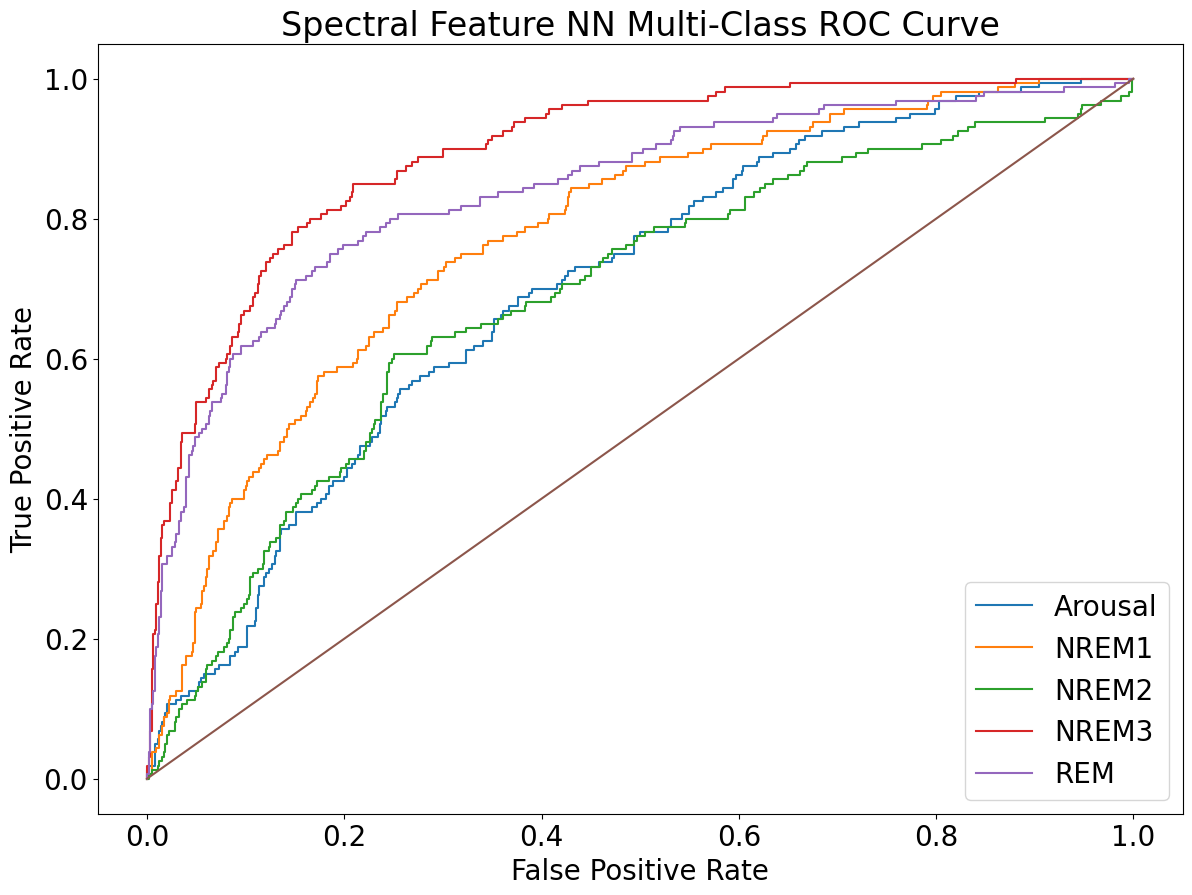

Spectral Feature NN -- AUCROC: 0.789, MCC: 0.201


In [ ]:
sf_val_pred = pd.DataFrame(sf_model.predict(sf_val_data))
sf_val_predict = sf_val_pred.idxmax(axis=1)
sf_val_labels_int = [np.where(label==1)[0][0] for label in sf_val_labels]
sf_val_labels_one_hot = pd.DataFrame(sf_val_labels)

sf_fpr, sf_tpr, sf_roc_auc = {}, {}, {}

plt.figure(figsize=(14, 10))
for i in range(5):
    sf_fpr[i], sf_tpr[i], _ = metrics.roc_curve(sf_val_labels_one_hot.iloc[:, i], sf_val_pred.iloc[:, i])
    sf_roc_auc[i] = metrics.auc(sf_fpr[i], sf_tpr[i])
    plt.plot(sf_fpr[i], sf_tpr[i], label=stage_dict[i])

plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Spectral Feature NN Multi-Class ROC Curve')
plt.legend()
plt.show()

sf_fpr['micro'], sf_tpr['micro'], _ = metrics.roc_curve(sf_val_labels_one_hot.values.ravel(), sf_val_pred.values.ravel())
sf_roc_auc_agg = metrics.auc(sf_fpr['micro'], sf_tpr['micro'])

y_true_sf, y_pred_sf = [], []
for i in range(sf_val_pred.shape[0]):
    y_pred_sf.append(1 if sf_val_predict.iloc[i]==0 else -1)
    y_true_sf.append(1 if sf_val_labels_int[i]==0 else -1)
sf_mcc = metrics.matthews_corrcoef(y_true_sf, y_pred_sf)

print(f"Spectral Feature NN -- AUCROC: {sf_roc_auc_agg:.3f}, MCC: {sf_mcc:.3f}")

###Ensemble

In [ ]:

ensemble_pred = (val_pred_a.values + rf_val_pred.values + sf_val_pred.values) / 3
ensemble_predict = pd.DataFrame(ensemble_pred).idxmax(axis=1)

fpr_e, tpr_e, _ = metrics.roc_curve(val_labels_a_onehot.values.ravel(), ensemble_pred.ravel())
roc_auc_agg_e = metrics.auc(fpr_e, tpr_e)

y_true_e, y_pred_e = [], []
for i in range(ensemble_pred.shape[0]):
    y_pred_e.append(1 if ensemble_predict.iloc[i]==0 else -1)
    y_true_e.append(1 if val_labels_a_int[i]==0 else -1)
mcc_e = metrics.matthews_corrcoef(y_true_e, y_pred_e)

print(f"Model A                AUCROC: {roc_auc_agg_a:.3f}, MCC: {mcc_a:.3f}")
print(f"Random Forest          AUCROC: {rf_roc_auc_agg:.3f}, MCC: {rf_mcc:.3f}")
print(f"Spectral Feature NN    AUCROC: {sf_roc_auc_agg:.3f}, MCC: {sf_mcc:.3f}")
print(f"3-Model Ensemble       AUCROC: {roc_auc_agg_e:.3f}, MCC: {mcc_e:.3f}")


ensemble_val_acc = np.mean(ensemble_predict.values == np.array(val_labels_a_int))
print(f"3-Model Ensemble    Validation Accuracy: {ensemble_val_acc:.3f}")

Model A                AUCROC: 0.900, MCC: 0.278
Random Forest          AUCROC: 0.894, MCC: 0.456
Spectral Feature NN    AUCROC: 0.789, MCC: 0.201
3-Model Ensemble       AUCROC: 0.907, MCC: 0.400
3-Model Ensemble    Validation Accuracy: 0.657


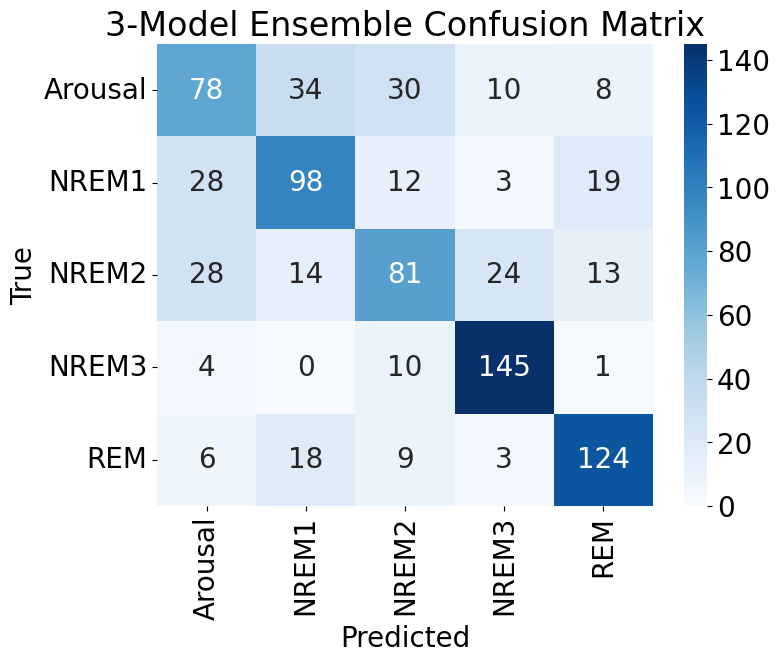

In [ ]:
cm_ensemble = confusion_matrix(val_labels_a_int, ensemble_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=[stage_dict[i] for i in range(5)],
            yticklabels=[stage_dict[i] for i in range(5)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('3-Model Ensemble Confusion Matrix')
plt.show()

###Test Data

In [ ]:
data_test_ds = down_size_sample(data_test_orig, down_size)
data_test_norm = (data_test_ds - signal_mean) / signal_std

g1_test = data_test_norm[:, :, g1_idx]
g2_test = data_test_norm[:, :, g2_idx]
g3_test = data_test_norm[:, :, g3_idx]

test_pred_a = model_a.predict([g1_test, g2_test, g3_test])
rf_test_pred = rf_model.predict_proba(rf_test_features)
sf_test_pred = sf_model.predict(sf_test_features)


ensemble_test_pred = (test_pred_a + rf_test_pred + sf_test_pred) / 3


test_output = np.ndarray(shape=(1000, 6))
for i in range(1000):
    test_output[i] = np.append(ensemble_test_pred[i], sf_test_order[i])
test_dataframe = pd.DataFrame(test_output)


sorted_test_dataframe = test_dataframe.sort_values(by=[5])


processed_test_dataframe = sorted_test_dataframe.drop(sorted_test_dataframe.columns[5], axis=1)

print(test_dataframe.head(), '\n\n', sorted_test_dataframe.head(), '\n\n', processed_test_dataframe.head())

file = 'EnsembleSubmission.xz'
processed_test_dataframe.to_pickle(file)
os.listdir('.')
files.download(file)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
          0         1         2         3         4    5
0  0.021298  0.079978  0.128314  0.720550  0.049860  0.0
1  0.469788  0.209399  0.188622  0.046894  0.085297  1.0
2  0.261595  0.225586  0.345019  0.015024  0.152776  2.0
3  0.205732  0.049330  0.407850  0.128388  0.208699  3.0
4  0.366482  0.150329  0.239088  0.149893  0.094208  4.0 

           0         1         2         3         4    5
0  0.021298  0.079978  0.128314  0.720550  0.049860  0.0
1  0.469788  0.209399  0.188622  0.046894  0.085297  1.0
2  0.261595  0.225586  0.345019  0.015024  0.152776  2.0
3  0.205732  0.049330  0.407850  0.128388  0.208699  3.0
4  0.366482  0.150329  0.239088  0.149893  0.094208  4.0 

           0         1         2         3         4
0  0.021298  0.079978  0.128314  0.720550  0.049860
1  0.469788  0.209399  0.188622  0.046894  0.085297
2  0.261595  0.225586  0.345019  0.015024  0.152776
3  0.205732  0.049330  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# XGBoost (eXtreme Gradient Boosting)

In [ ]:
import xgboost as xgb

In [ ]:
y_train_int = np.argmax(partial_train_labels, axis=1)
y_val_int = np.argmax(val_labels, axis=1)

sample_weights = compute_sample_weight("balanced", y_train_int)


# create model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(partial_train_data, y_train_int, sample_weight=sample_weights)

# validation score
val_pred_proba = xgb_model.predict_proba(val_data)
val_pred = xgb_model.predict(val_data)

NameError: name 'partial_train_labels' is not defined

In [ ]:
# AUC Curve + MCC
xgb_fpr, xgb_tpr, xgb_roc_auc = {}, {}, {}

plt.figure(figsize=(14,10))
for i in range(5):
    xgb_fpr[i], xgb_tpr[i], _ = metrics.roc_curve(val_labels[:, i], val_pred_proba[:, i])
    xgb_roc_auc[i] = metrics.auc(xgb_fpr[i], xgb_tpr[i])
    plt.plot(xgb_fpr[i], xgb_tpr[i], label = stage_dict[i] + ", " + str(i))

plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost Multi-Class ROC Curve")
plt.legend()
plt.show()

xgb_fpr["micro"], xgb_tpr["micro"], _ = metrics.roc_curve(val_labels.ravel(), val_pred_proba.ravel())
xgb_roc_auc_agg = metrics.auc(xgb_fpr["micro"], xgb_tpr["micro"])
xg_mcc = metrics.matthews_corrcoef(y_true, y_pred)

print(f"XGBoost AUCROC: {xgb_roc_auc_agg:.3f}")
print(f"XGBoost MCC: {xg_mcc:.3f}")

In [ ]:
y_true, y_pred = [], []
for i in range(val_pred.shape[0]):
    y_pred.append(1 if val_pred[i] == 0 else -1)
    y_true.append(1 if y_val_int[i] == 0 else -1)
xg_mcc = metrics.matthews_corrcoef(y_true, y_pred)

In [ ]:
# confuion metrics viz
cm = confusion_matrix(y_val_int, val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[stage_dict[i] for i in range(5)],
            yticklabels=[stage_dict[i] for i in range(5)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('XG Boost Confusion Matrix')
plt.show()

In [ ]:
# Validation Accuracy
xgboost_val_acc = np.mean(val_pred == y_val_int)
print(xgboost_val_acc)

# 1D **CNN**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
# cnn outline
num_classes = 5
model = nn.Sequential(
    nn.Conv1d(1, 16, kernel_size=2, padding="same"),
    nn.ReLU(),
    nn.Flatten(),
    nn.LazyLinear(num_classes)
)


In [ ]:
X_tr = partial_train_data
y_tr = partial_train_labels
X_vld = val_data

X_tr= X_tr.reshape(-1, 1, 7)
X_vld= X_vld.reshape(-1, 1, 7)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
import torch.optim as optim # Import optim module
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_tr, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.long).argmax(dim=1)
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_vld, dtype=torch.float32),
    torch.tensor(val_labels, dtype=torch.long).argmax(dim=1)
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size)

for epoch in range(epochs):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_correct += torch.sum(preds == labels).item()
        running_total += labels.size(0)
    tr_loss = running_loss / running_total
    tr_acc = running_correct / running_total

    model.eval()
    val_loss_total, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs_v, labels_v in val_loader:
            inputs_v, labels_v = inputs_v.to(device), labels_v.to(device)
            outputs = model(inputs_v)
            preds = torch.argmax(outputs, dim=1)
            val_loss_total += criterion(outputs, labels_v).item() * inputs_v.size(0)
            val_correct += torch.sum(preds == labels_v).item()
            val_total += labels_v.size(0)
    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    print('Epoch #%d\tTrain Loss: %.3f\tTrain Acc: %.3f\tVal Loss: %.3f\tVal Acc: %.3f'
          % (epoch+1, tr_loss, tr_acc, val_loss, val_acc))

In [ ]:
# viz of the loss and train accurcy
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Plot train and plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plotting train anc validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Training Accuracy")
plt.plot(epochs_range, val_accs, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
fpr_a, tpr_a, roc_auc_a = {}, {}, {}


val_preds_list = []
with torch.no_grad():
    for inputs_v, _ in val_loader:
        inputs_v = inputs_v.to(device)
        outputs = model(inputs_v)
        probabilities = torch.softmax(outputs, dim=1)
        val_preds_list.append(probabilities.cpu().numpy())

val_pred_a = pd.DataFrame(np.concatenate(val_preds_list))
val_labels_a_onehot = pd.DataFrame(val_labels)

plt.figure(figsize=(14, 10))
for i in range(5):
    fpr_a[i], tpr_a[i], _ = metrics.roc_curve(val_labels_a_onehot.iloc[:, i], val_pred_a.iloc[:, i])
    roc_auc_a[i] = metrics.auc(fpr_a[i], tpr_a[i])
    plt.plot(fpr_a[i], tpr_a[i], label=stage_dict[i] + ', ' + str(i))

plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" 1D CNN ROC Curve")
plt.legend()
plt.show()

fpr_a["micro"], tpr_a["micro"], _ = metrics.roc_curve(val_labels_a_onehot.values.ravel(), val_pred_a.values.ravel())
roc_auc_agg_a = metrics.auc(fpr_a["micro"], tpr_a["micro"])

In [ ]:
# confusion matrix
y_val_cnn_int = np.argmax(val_labels, axis=1)

val_pred_cnn_int = np.argmax(val_pred_a.values, axis=1)

cm = confusion_matrix(y_val_cnn_int, val_pred_cnn_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[stage_dict[i] for i in range(5)],
            yticklabels=[stage_dict[i] for i in range(5)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('1D CNN Confusion Matrix')



In [ ]:

print("AUC:", roc_auc_agg_a)